# Flight Delay Prediction: Data Processing & Benchmark Modeling

## Overview
This notebook covers the end-to-end process of preparing a large-scale flight dataset for machine learning and establishing baseline models.

The workflow includes:
1.  **Data Ingestion**: Loading multiple months of flight performance data from CSV files.
2.  **Optimization**: converting heavy CSVs into a unified, compressed **Parquet** file for efficiency.
3.  **Data Cleaning**: Filtering relevant columns, handling missing values, and typecasting to reduce memory usage.
4.  **Feature Engineering**: Creates temporal features (Weekend, MonthPart), time-blocks (Peak hours), and statistical features (Target Encoding for Airlines/Airports).
5.  **Modeling**: Training **Random Forest (cuML)** and **XGBoost** regressors to predict flight delays (`ArrDelayMinutes`).

### 1. Library Imports
We start by importing standard data manipulation libraries (`pandas`, `numpy`) and visualization tools.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Data Loading
The dataset is split across multiple CSV files. We load them sequentially. 

In [ ]:
df1 = pd.read_csv("On_Time_Marketing_Carrier_On_Time_Performance_Beginning_January_2018_2025_1\On_Time_Marketing_Carrier_On_Time_Performance_(Beginning_January_2018)_2025_1.csv")
df1.info()

C:\Users\mehta\AppData\Local\Temp\ipykernel_18712\3345811487.py:1: DtypeWarning: Columns (11,13,78,85,86,93) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("On_Time_Marketing_Carrier_On_Time_Performance_Beginning_January_2018_2025_1\On_Time_Marketing_Carrier_On_Time_Performance_(Beginning_January_2018)_2025_1.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599013 entries, 0 to 599012
Columns: 120 entries, Year to Unnamed: 119
dtypes: float64(72), int64(23), object(25)
memory usage: 548.4+ MB


In [ ]:
df2 = pd.read_csv("On_Time_Marketing_Carrier_On_Time_Performance_Beginning_January_2018_2025_2\On_Time_Marketing_Carrier_On_Time_Performance_(Beginning_January_2018)_2025_2.csv")
df2.info()

C:\Users\mehta\AppData\Local\Temp\ipykernel_18712\1558680199.py:1: DtypeWarning: Columns (11,13,86,93,94) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("On_Time_Marketing_Carrier_On_Time_Performance_Beginning_January_2018_2025_2\On_Time_Marketing_Carrier_On_Time_Performance_(Beginning_January_2018)_2025_2.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 559577 entries, 0 to 559576
Columns: 120 entries, Year to Unnamed: 119
dtypes: float64(71), int64(23), object(26)
memory usage: 512.3+ MB


In [ ]:
df3 = pd.read_csv("On_Time_Marketing_Carrier_On_Time_Performance_Beginning_January_2018_2025_3\On_Time_Marketing_Carrier_On_Time_Performance_(Beginning_January_2018)_2025_3.csv")
df3.info()

C:\Users\mehta\AppData\Local\Temp\ipykernel_18712\1253618568.py:1: DtypeWarning: Columns (11,13,78,85,86,93) have mixed types. Specify dtype option on import or set low_memory=False.
  df3 = pd.read_csv("On_Time_Marketing_Carrier_On_Time_Performance_Beginning_January_2018_2025_3\On_Time_Marketing_Carrier_On_Time_Performance_(Beginning_January_2018)_2025_3.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 664932 entries, 0 to 664931
Columns: 120 entries, Year to Unnamed: 119
dtypes: float64(72), int64(23), object(25)
memory usage: 608.8+ MB


In [ ]:
df4 = pd.read_csv("On_Time_Marketing_Carrier_On_Time_Performance_Beginning_January_2018_2025_4\On_Time_Marketing_Carrier_On_Time_Performance_(Beginning_January_2018)_2025_4.csv")
df4.info()

C:\Users\mehta\AppData\Local\Temp\ipykernel_18712\3103829373.py:1: DtypeWarning: Columns (11,13,86,93) have mixed types. Specify dtype option on import or set low_memory=False.
  df4 = pd.read_csv("On_Time_Marketing_Carrier_On_Time_Performance_Beginning_January_2018_2025_4\On_Time_Marketing_Carrier_On_Time_Performance_(Beginning_January_2018)_2025_4.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 644084 entries, 0 to 644083
Columns: 120 entries, Year to Unnamed: 119
dtypes: float64(72), int64(23), object(25)
memory usage: 589.7+ MB


In [ ]:
df5 = pd.read_csv("On_Time_Marketing_Carrier_On_Time_Performance_Beginning_January_2018_2025_5\On_Time_Marketing_Carrier_On_Time_Performance_(Beginning_January_2018)_2025_5.csv")
df5.info()

C:\Users\mehta\AppData\Local\Temp\ipykernel_18712\614058276.py:1: DtypeWarning: Columns (11,13,86,93) have mixed types. Specify dtype option on import or set low_memory=False.
  df5 = pd.read_csv("On_Time_Marketing_Carrier_On_Time_Performance_Beginning_January_2018_2025_5\On_Time_Marketing_Carrier_On_Time_Performance_(Beginning_January_2018)_2025_5.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 667586 entries, 0 to 667585
Columns: 120 entries, Year to Unnamed: 119
dtypes: float64(72), int64(23), object(25)
memory usage: 611.2+ MB


In [ ]:
df6 = pd.read_csv("On_Time_Marketing_Carrier_On_Time_Performance_Beginning_January_2018_2025_6\On_Time_Marketing_Carrier_On_Time_Performance_(Beginning_January_2018)_2025_6.csv")
df6.info()

C:\Users\mehta\AppData\Local\Temp\ipykernel_18712\2057199409.py:1: DtypeWarning: Columns (11,13,86,93,94,101) have mixed types. Specify dtype option on import or set low_memory=False.
  df6 = pd.read_csv("On_Time_Marketing_Carrier_On_Time_Performance_Beginning_January_2018_2025_6\On_Time_Marketing_Carrier_On_Time_Performance_(Beginning_January_2018)_2025_6.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 674179 entries, 0 to 674178
Columns: 120 entries, Year to Unnamed: 119
dtypes: float64(70), int64(23), object(27)
memory usage: 617.2+ MB


In [ ]:
df7 = pd.read_csv("On_Time_Marketing_Carrier_On_Time_Performance_(Beginning_January_2018)_2025_7.csv")
df7.info()

C:\Users\mehta\AppData\Local\Temp\ipykernel_18712\1075470697.py:1: DtypeWarning: Columns (11,13,86,93) have mixed types. Specify dtype option on import or set low_memory=False.
  df7 = pd.read_csv("On_Time_Marketing_Carrier_On_Time_Performance_(Beginning_January_2018)_2025_7.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 696049 entries, 0 to 696048
Columns: 120 entries, Year to Unnamed: 119
dtypes: float64(72), int64(23), object(25)
memory usage: 637.3+ MB


### 3. Merging Data
To avoid format mismatches during concatenation, we first cast all columns to string type temporarily, then concatenate all dataframes into a single `final_df`.

In [ ]:
dfs = [df1, df2, df3, df4, df5, df6, df7]

for i in range(len(dfs)):
    dfs[i] = dfs[i].astype(str)

In [ ]:
final_df = pd.concat(dfs, ignore_index=True)

In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4505420 entries, 0 to 4505419
Columns: 120 entries, Year to Unnamed: 119
dtypes: object(120)
memory usage: 4.0+ GB


### 4. Parquet Optimization
We save the raw combined data as a **Parquet** file. Parquet is much faster to read/write and efficient for storage compared to CSV.

In [ ]:
final_df.to_parquet("Flight-Delay-Data.parquet")

### 5. Advanced Cleaning with PyArrow
Handling 4.5 million+ rows in Pandas can be memory-intensive. Here, we use `pyarrow` to process the file in batches (chunks).

**Key steps in this block:**
- Define strict schemas (Lists of columns for Numeric, Categorical, Boolean, Time).
- **`fix_hhmm`**: A helper to convert time strings (e.g., "0830") into standard Datetime objects.
- Iterate through the file in chunks of 200,000 rows, apply cleaning, downcast types, and write to a new "Cleaned" Parquet file.

In [ ]:
import pyarrow.parquet as pq
import pyarrow as pa
import pyarrow.dataset as ds
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import os

In [ ]:
INPUT_FILE = "/content/drive/MyDrive/Flight-Delay-Data.parquet"
OUTPUT_FILE = "/content/drive/MyDrive/Flight-Delay-Data-Cleaned.parquet"

if os.path.exists(OUTPUT_FILE):
    os.remove(OUTPUT_FILE)

pf = pq.ParquetFile(INPUT_FILE)

keep_cols = [

    "Year", "Quarter", "Month", "DayofMonth", "DayOfWeek",

    "OriginAirportID", "DestAirportID",
    "OriginState", "DestState",

    "Marketing_Airline_Network", "Operating_Airline ",

    "CRSDepTime", "CRSArrTime",
    "DepTimeBlk", "ArrTimeBlk",

    "Distance", "DistanceGroup", "Flights",

    "DepDelay", "DepDelayMinutes", "DepDel15",
    "ArrDelay", "ArrDelayMinutes", "ArrDel15",

    "TaxiOut", "TaxiIn", "AirTime",
    "CRSElapsedTime", "ActualElapsedTime",

    "Cancelled", "Diverted"
]

numeric_cols = [
    "Year","Quarter","Month","DayofMonth","DayOfWeek",
    "Flights","Distance","DistanceGroup",
]

delay_cols = [
    "DepDelay","DepDelayMinutes","DepDel15",
    "ArrDelay","ArrDelayMinutes","ArrDel15",
    "DepartureDelayGroups","ArrivalDelayGroups"
]

time_numeric_cols = ["TaxiOut","TaxiIn","AirTime","CRSElapsedTime","ActualElapsedTime"]

bool_cols = ["Cancelled","Diverted"]

def fix_hhmm(series):
    s = series.fillna("").astype(str).str.zfill(4)
    return pd.to_datetime(s, format="%H%M", errors="coerce")

first_batch = True
writer = None

for batch in pf.iter_batches(batch_size=200000):
    df = batch.to_pandas()
    df = df[[c for c in keep_cols if c in df.columns]]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    for col in delay_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    for col in time_numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    for col in bool_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")
    for col in ["CRSDepTime","CRSArrTime"]:
        if col in df.columns:
            df[col] = fix_hhmm(df[col])
    cat_cols = [
        "OriginState","DestState",
        "Marketing_Airline_Network","Operating_Airline ",
        "DepTimeBlk","ArrTimeBlk"
    ]
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype("category")
    table = pa.Table.from_pandas(df, preserve_index=False)
    if first_batch:
        writer = pq.ParquetWriter(OUTPUT_FILE, table.schema)
        first_batch = False
    writer.write_table(table)
    print("Chunk processed:", df.shape)
if writer:
    writer.close()
print("Completed. Clean file saved as:", OUTPUT_FILE)

Chunk processed: (200000, 31)
Chunk processed: (200000, 31)
Chunk processed: (200000, 31)
Chunk processed: (200000, 31)
Chunk processed: (200000, 31)
Chunk processed: (200000, 31)
Chunk processed: (200000, 31)
Chunk processed: (200000, 31)
Chunk processed: (200000, 31)
Chunk processed: (200000, 31)
Chunk processed: (200000, 31)
Chunk processed: (200000, 31)
Chunk processed: (200000, 31)
Chunk processed: (200000, 31)
Chunk processed: (200000, 31)
Chunk processed: (200000, 31)
Chunk processed: (200000, 31)
Chunk processed: (200000, 31)
Chunk processed: (200000, 31)
Chunk processed: (200000, 31)
Chunk processed: (200000, 31)
Chunk processed: (200000, 31)
Chunk processed: (105420, 31)
Completed. Clean file saved as: /content/drive/MyDrive/Flight-Delay-Data-Cleaned.parquet


### 6. Loading Cleaned Data
Now that the data is processed, we load the cleaned Parquet file directly. 


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_parquet(
    "https://drive.google.com/uc?export=download&id=1_t9oy9KMJF5L1RXm7p53UJMX3DaXyTV0"
)

### 7. Second Pass Cleaning
We define the list of columns to be used for the final modeling stage and perform a second pass of type enforcement to ensure memory efficiency.

In [ ]:
df.columns = df.columns.str.strip()
keep_cols = [
    "Year", "Quarter", "Month", "DayofMonth", "DayOfWeek",
    "OriginAirportID", "DestAirportID",
    "OriginState", "DestState",
    "Marketing_Airline_Network", "Operating_Airline",
    "CRSDepTime", "CRSArrTime",
    "DepTimeBlk", "ArrTimeBlk",
    "Distance", "DistanceGroup", "Flights",
    "DepDelay", "DepDelayMinutes", "DepDel15",
    "ArrDelay", "ArrDelayMinutes", "ArrDel15",
    "TaxiOut", "TaxiIn", "AirTime",
    "CRSElapsedTime", "ActualElapsedTime",
    "Cancelled", "Diverted"
]

In [ ]:
numeric_cols = [
    "Year","Quarter","Month","DayofMonth","DayOfWeek",
    "Flights","Distance","DistanceGroup",
]

delay_cols = [
    "DepDelay","DepDelayMinutes","DepDel15",
    "ArrDelay","ArrDelayMinutes","ArrDel15",
    "DepartureDelayGroups","ArrivalDelayGroups"
]

time_numeric_cols = ["TaxiOut","TaxiIn","AirTime","CRSElapsedTime","ActualElapsedTime"]

bool_cols = ["Cancelled","Diverted"]

In [ ]:
def fix_hhmm(series):
    s = series.fillna("").astype(str).str.zfill(4)
    return pd.to_datetime(s, format="%H%M", errors="coerce").dt.time

In [ ]:
print("Starting data cleaning...")

df = df[[c for c in keep_cols if c in df.columns]]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

for col in delay_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

for col in time_numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

for col in bool_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

for col in ["CRSDepTime","CRSArrTime"]:
    if col in df.columns:
        df[col] = fix_hhmm(df[col])

cat_cols = [
    "OriginState","DestState",
    "Marketing_Airline_Network","Operating_Airline",
    "DepTimeBlk","ArrTimeBlk"
]
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

print("Data cleaning completed.")
print("The cleaned DataFrame is now stored in the variable 'df'.")

Starting data cleaning...
Data cleaning completed.
The cleaned DataFrame is now stored in the variable 'df'.


In [ ]:
df.columns = df.columns.str.strip()
print("Initial shape:", df.shape)

Initial shape: (4505420, 31)


### 8. Filtering & null Handling
- We drop redundant columns (like `Quarter`, `OriginState`) to simplify the feature set.
- Rows with missing `ArrDelayMinutes` or `CRSElapsedTime` are removed as they are essential for prediction.
- We exclude **Cancelled** or **Diverted** flights from the dataset.

In [ ]:
keep_cols = [
    "Year","Quarter","Month","DayofMonth","DayOfWeek",
    "OriginAirportID","DestAirportID",
    "OriginState","DestState",
    "Marketing_Airline_Network","Operating_Airline",
    "CRSDepTime","CRSArrTime",
    "DepTimeBlk","ArrTimeBlk",
    "Distance","DistanceGroup","Flights",
    "DepDelay","DepDelayMinutes","DepDel15",
    "ArrDelay","ArrDelayMinutes","ArrDel15",
    "TaxiOut","TaxiIn","AirTime",
    "CRSElapsedTime","ActualElapsedTime",
    "Cancelled","Diverted"
]

In [ ]:
df = df[[c for c in keep_cols if c in df.columns]]

numeric_cols = [
    "Year","Quarter","Month","DayofMonth","DayOfWeek",
    "Flights","Distance","DistanceGroup",
    "TaxiOut","TaxiIn","AirTime",
    "CRSElapsedTime","ActualElapsedTime",
    "DepDelay","DepDelayMinutes","ArrDelay","ArrDelayMinutes"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["Cancelled","Diverted"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

cat_cols = [
    "OriginState","DestState",
    "Marketing_Airline_Network","Operating_Airline",
    "DepTimeBlk","ArrTimeBlk"
]

for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

cols_to_drop = [
    "Quarter","Marketing_Airline_Network",
    "CRSDepTime","CRSArrTime",
    "Flights","TaxiOut","TaxiIn","AirTime",
    "ActualElapsedTime","OriginState","DestState",
    "Year","ArrDel15","ArrDelay",
    "DepDelay","DepDelayMinutes","DepDel15"
]

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
df = df.dropna(subset=["ArrDelayMinutes", "CRSElapsedTime"])
df = df[df["Cancelled"] != 1]
df = df[df["Diverted"] != 1]
df = df.drop(columns=["Cancelled","Diverted"])

print("After cleaning:", df.shape)

After cleaning: (4414300, 12)


### 9. Basic Exploratory Data Analysis
We create new graphs for outliers and correlation to understand the data:
1.  **HistPlot Distribution**
2.  **Outliers Boxplot**
3.  **Correlation Matrix**

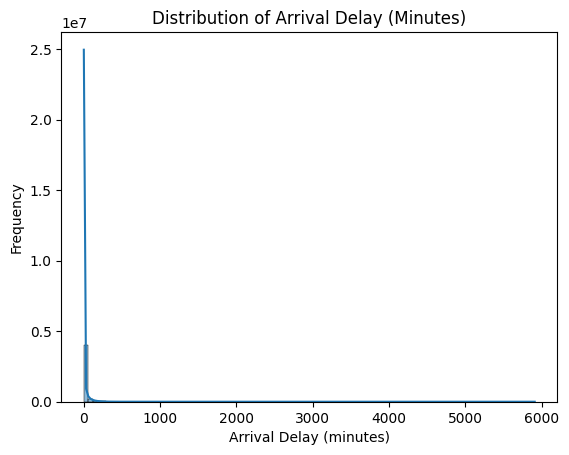

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
sns.histplot(df["ArrDelayMinutes"], bins=100, kde=True)
plt.title("Distribution of Arrival Delay (Minutes)")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Frequency")
plt.show()

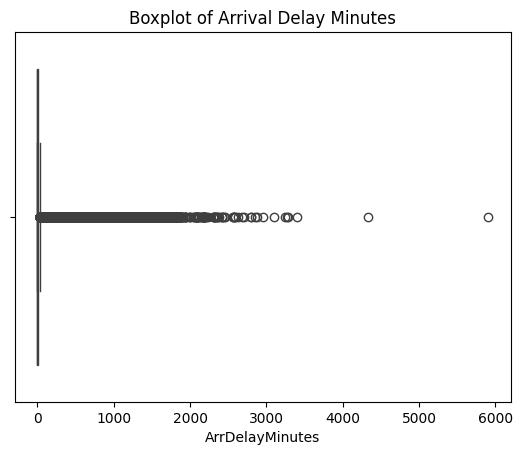

In [ ]:
plt.figure()
sns.boxplot(x=df["ArrDelayMinutes"])
plt.title("Boxplot of Arrival Delay Minutes")
plt.show()

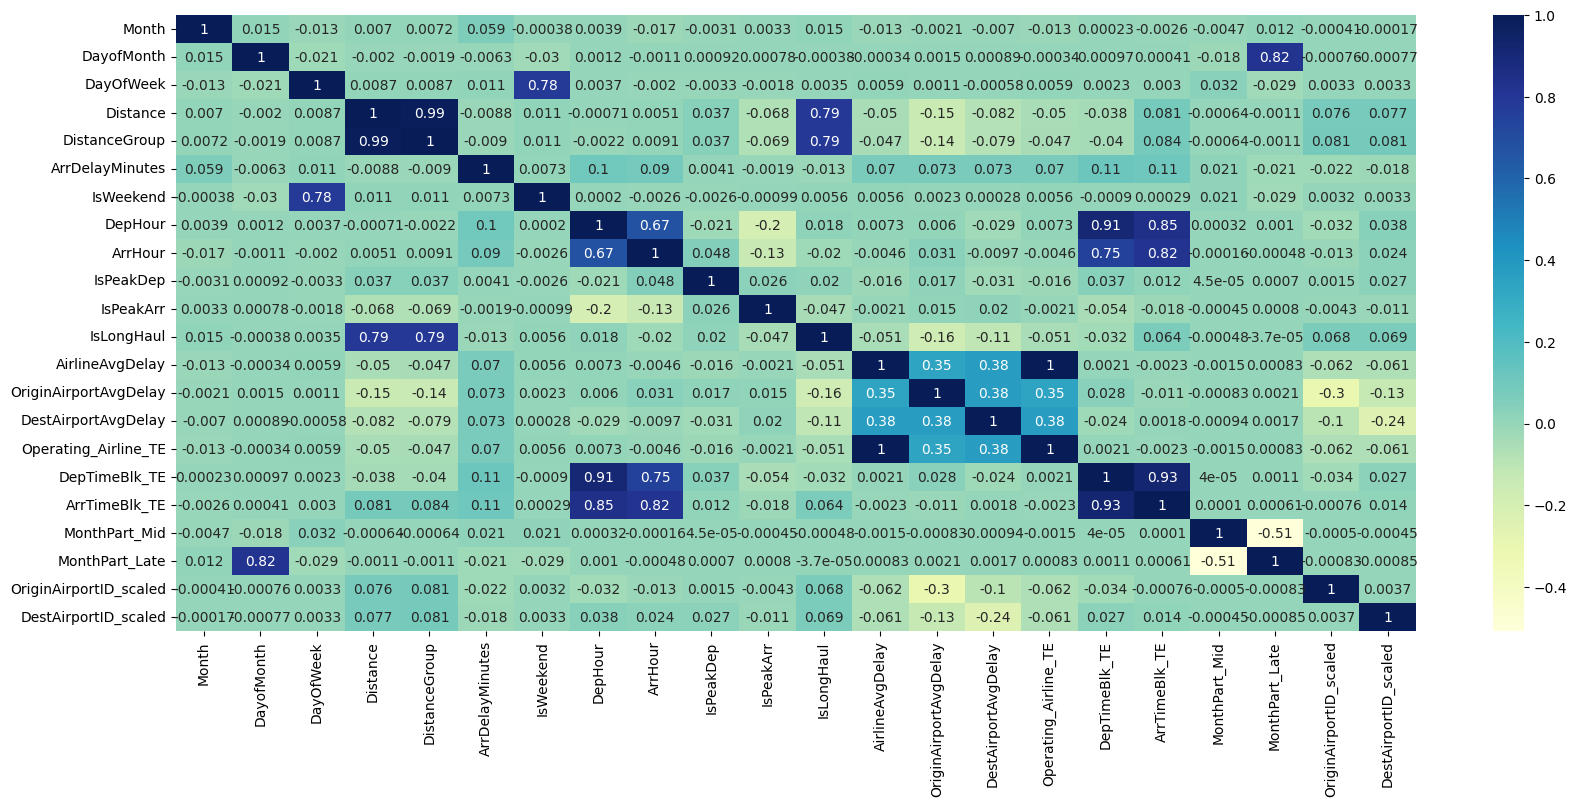

In [ ]:
plt.figure(figsize=(20,8))
sns.heatmap(df.corr(),annot = True, cmap = 'YlGnBu')
plt.show()

### 10. Feature Engineering
We create new features to help the model learn patterns:
1.  **Calendar Features**: `IsWeekend` (Sat/Sun) and `MonthPart` (Early/Mid/Late month).
2.  **Time Blocks**: Extracting Hours and flagging **Peak** departure/arrival hours.
3.  **Route Efficiency**: `IsLongHaul` for flights > 1500 miles.
4.  **Target Encoding (History)**: Calculating the mean delay for each Airline and Airport. 
    > *Note: This computes average delays based on the dataset to provide historical context to the model.*

In [ ]:
# Calendar
df["IsWeekend"] = df["DayOfWeek"].isin([6,7]).astype(int)

df["MonthPart"] = pd.cut(
    df["DayofMonth"],
    bins=[0,10,20,31],
    labels=["Early","Mid","Late"]
)
# Time blocks
df["DepHour"] = df["DepTimeBlk"].str.slice(0,2).astype(int)
df["ArrHour"] = df["ArrTimeBlk"].str.slice(0,2).astype(int)

df["IsPeakDep"] = df["DepHour"].isin([7,8,9,17,18,19]).astype(int)
df["IsPeakArr"] = df["ArrHour"].isin([7,8,9,17,18,19]).astype(int)

# Route efficiency
df["IsLongHaul"] = (df["Distance"] > 1500).astype(int)

# Historical aggregates (OK for baseline)
df["AirlineAvgDelay"] = df.groupby("Operating_Airline")["ArrDelayMinutes"].transform("mean")
df["OriginAirportAvgDelay"] = df.groupby("OriginAirportID")["ArrDelayMinutes"].transform("mean")
df["DestAirportAvgDelay"] = df.groupby("DestAirportID")["ArrDelayMinutes"].transform("mean")

### 11. Final Preparation
- Apply Target Encoding to remaining categorical blocks (`Operating_Airline`, `DepTimeBlk`, `ArrTimeBlk`).
- Drop original categorical columns after encoding.
- One-hot encode `MonthPart`.

In [ ]:
for col in ["Operating_Airline","DepTimeBlk","ArrTimeBlk"]:
    df[col + "_TE"] = df.groupby(col)["ArrDelayMinutes"].transform("mean")

df = df.drop(columns=["Operating_Airline","DepTimeBlk","ArrTimeBlk","CRSElapsedTime"])

# Ensure numeric
for col in [
    "AirlineAvgDelay",
    "Operating_Airline_TE",
    "DepTimeBlk_TE",
    "ArrTimeBlk_TE"
]:
    df[col] = df[col].astype("float32")

# One-hot MonthPart
df = pd.get_dummies(df, columns=["MonthPart"], drop_first=True)

print("After feature engineering:", df.shape)

/tmp/ipython-input-1683692276.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col + "_TE"] = df.groupby(col)["ArrDelayMinutes"].transform("mean")
/tmp/ipython-input-1683692276.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col + "_TE"] = df.groupby(col)["ArrDelayMinutes"].transform("mean")
/tmp/ipython-input-1683692276.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col + "_TE"] = df.groupby(col)["A

After feature engineering: (4414300, 22)


### 12. Train/Test Split
We split the data into **70% Training** and **30% Testing** sets. 
- **Target**: `ArrDelayMinutes`
- **Features**: All other columns except IDs and Target.

In [ ]:
from sklearn.model_selection import train_test_split
TARGET = "ArrDelayMinutes"
ID_COLS = ["OriginAirportID","DestAirportID"]

FEATURES = [c for c in df.columns if c not in ID_COLS + [TARGET]]

train_df, test_df = train_test_split(
    df, test_size=0.30, random_state=42
)

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]

In [ ]:
print("Max delay (train):", y_train.max())
print("99.9 percentile :", y_train.quantile(0.999))
print("99.5 percentile :", y_train.quantile(0.995))
print("Count > 300     :", (y_train > 300).sum())

Max delay (train): 5907.0
99.9 percentile : 805.9910000003874
99.5 percentile : 320.0
Count > 300     : 17855


### 13. Target Capping
To handle extreme outliers (e.g., 24-hour delays), we cap the target variable at **320 minutes**. This prevents the model from being skewed by rare, extreme events.

In [ ]:
DELAY_CAP = 320

y_train_capped = y_train.clip(upper=DELAY_CAP)
y_test_capped  = y_test.clip(upper=DELAY_CAP)

print("Final shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Max delay (train):", y_train_capped.max())
print("Max delay (test) :", y_test_capped.max())

Final shapes:
X_train: (3090010, 19)
X_test : (1324290, 19)
Max delay (train): 320.0
Max delay (test) : 320.0


In [ ]:
print("Max delay (train):", y_train_capped.max())
print("99.9 percentile :", y_train_capped.quantile(0.999))
print("99.5 percentile :", y_train_capped.quantile(0.995))
print("Count > 300     :", (y_train_capped > 300).sum())

Max delay (train): 320.0
99.9 percentile : 320.0
99.5 percentile : 320.0
Count > 300     : 17855


### 14. GPU Random Forest
We use **cuML's RandomForestRegressor** (from RAPIDS) to train on the GPU. This is significantly faster than CPU-based sklearn for large datasets.

In [ ]:
import numpy as np
from cuml.ensemble import RandomForestRegressor
from cuml.metrics import mean_absolute_error, mean_squared_error, r2_score

rf = RandomForestRegressor(
    n_estimators=200,       
    max_depth=20,           
    min_samples_leaf=50,    
    min_samples_split=50,   
    max_features="sqrt",    
    random_state=42,        
    verbose = 1
)

rf.fit(X_train, y_train_capped)

rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)

print("\nGPU RANDOM FOREST PERFORMANCE")
print("Train MAE :", mean_absolute_error(y_train_capped, rf_train_pred))
print("Test MAE :", mean_absolute_error(y_test_capped, rf_test_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test_capped, rf_test_pred)))
print("Test R² :", r2_score(y_test_capped, rf_test_pred))

`GPU RANDOM FOREST PERFORMANCE`

`Train MAE : 21.855989022260495`

`Test MAE : 22.357804620900495`

`Test RMSE: 41.44764599388247`

`Test R² : 0.08089993497601589`

### 15. XGBoost Model
We also train an **XGBoost Regressor**, which often captures non-linear relationships better.
Key parameters:
- `tree_method="hist"`: Uses an optimized histogram-based algorithm for speed.

In [ ]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test_capped)],
    verbose=50
)

xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred  = xgb_model.predict(X_test)

print("\nOLD XGBOOST PERFORMANCE (Baseline)")
print("Train MAE :", mean_absolute_error(y_train_capped, xgb_train_pred))
print("Test  MAE :", mean_absolute_error(y_test_capped, xgb_test_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test_capped, xgb_test_pred)))
print("Test R²  :", r2_score(y_test_capped, xgb_test_pred))

[0]	validation_0-rmse:43.10456
[50]	validation_0-rmse:41.14626
[100]	validation_0-rmse:40.80169
[150]	validation_0-rmse:40.63573
[200]	validation_0-rmse:40.52989
[250]	validation_0-rmse:40.43272
[300]	validation_0-rmse:40.37652
[350]	validation_0-rmse:40.31329
[400]	validation_0-rmse:40.25328
[450]	validation_0-rmse:40.20558
[499]	validation_0-rmse:40.17443

OLD XGBOOST PERFORMANCE (Baseline)
Train MAE : 21.504740051803186
Test  MAE : 21.79234429318835
Test RMSE: 40.17443077554542
Test R²  : 0.13649964396890635


### 16. Fine Tuning Hyperparameters
Key Parameters:
- `objective="reg:pseudohubererror"`: A robust loss function that is less sensitive to outliers than squared error.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "min_child_weight": [10, 30, 50, 80],
    "max_depth": [5, 6, 7, 8],
    "learning_rate": [0.03, 0.04],
    "n_estimators": [600, 800]
}

xgb_base = xgb.XGBRegressor(
    objective="reg:pseudohubererror",
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    device="cuda",
    random_state=42
)

grid = GridSearchCV(
    xgb_base,
    param_grid,
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=1,
    verbose=2
)

grid.fit(X_train, y_train_capped)

print("Best MAE:", -grid.best_score_)
print("Best params:", grid.best_params_)

Fitting 3 folds for each of 64 candidates, totalling 192 fits
[CV] END learning_rate=0.03, max_depth=5, min_child_weight=10, n_estimators=600; total time=   7.5s
[CV] END learning_rate=0.03, max_depth=5, min_child_weight=10, n_estimators=600; total time=   7.5s
[CV] END learning_rate=0.03, max_depth=5, min_child_weight=10, n_estimators=600; total time=   7.5s
[CV] END learning_rate=0.03, max_depth=5, min_child_weight=10, n_estimators=800; total time=   8.9s
[CV] END learning_rate=0.03, max_depth=5, min_child_weight=10, n_estimators=800; total time=   9.0s
[CV] END learning_rate=0.03, max_depth=5, min_child_weight=10, n_estimators=800; total time=   9.0s
[CV] END learning_rate=0.03, max_depth=5, min_child_weight=30, n_estimators=600; total time=   7.4s
[CV] END learning_rate=0.03, max_depth=5, min_child_weight=30, n_estimators=600; total time=   7.6s
[CV] END learning_rate=0.03, max_depth=5, min_child_weight=30, n_estimators=600; total time=   7.6s
[CV] END learning_rate=0.03, max_depth

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

xgb_model = xgb.XGBRegressor(
    objective="reg:pseudohubererror",
    n_estimators=800,
    learning_rate=0.04,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    tree_method="hist",
    device = 'cuda',
    random_state=42
)


xgb_model.fit(
    X_train,
    y_train_capped,
    eval_set=[(X_test, y_test_capped)],
    verbose=50
)

xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

print("\nXGBOOST PERFORMANCE")
print("Train MAE :", mean_absolute_error(y_train_capped, xgb_train_pred))
print("Test  MAE :", mean_absolute_error(y_test_capped, xgb_test_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test_capped, xgb_test_pred)))
print("Test R²  :", r2_score(y_test_capped, xgb_test_pred))

[0]	validation_0-mphe:16.49841
[50]	validation_0-mphe:16.19243
[100]	validation_0-mphe:16.05181
[150]	validation_0-mphe:15.99311
[200]	validation_0-mphe:15.96868
[250]	validation_0-mphe:15.94576
[300]	validation_0-mphe:15.92872
[350]	validation_0-mphe:15.91481
[400]	validation_0-mphe:15.89986
[450]	validation_0-mphe:15.88192
[500]	validation_0-mphe:15.87016
[550]	validation_0-mphe:15.85715
[600]	validation_0-mphe:15.84661
[650]	validation_0-mphe:15.83745
[700]	validation_0-mphe:15.82750
[750]	validation_0-mphe:15.81645
[799]	validation_0-mphe:15.80670


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [16:08:33] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



XGBOOST PERFORMANCE
Train MAE : 16.354775819736883
Test  MAE : 16.432258630240806
Test RMSE: 43.919700542821275
Test R²  : -0.03200499069198881


In [ ]:
SAMPLE_SIZE = 50

sample_df = X_test.sample(n=SAMPLE_SIZE, random_state=42)
sample_true = y_test_capped.loc[sample_df.index]

sample_pred = xgb_model.predict(sample_df)
sample_pred = np.clip(sample_pred, 0, None)

In [ ]:
def within_x_minutes_accuracy(y_true, y_pred, x):
    return (np.abs(y_true - y_pred) <= x).mean() * 100

acc_5 = within_x_minutes_accuracy(sample_true.values, sample_pred, 5)
acc_10 = within_x_minutes_accuracy(sample_true.values, sample_pred, 10)
acc_15 = within_x_minutes_accuracy(sample_true.values, sample_pred, 15)

print(f"Accuracy within ±5 min: {acc_5:.2f}%")
print(f"Accuracy within ±10 min: {acc_10:.2f}%")
print(f"Accuracy within ±15 min: {acc_15:.2f}%")

Accuracy within ±5 min: 70.00%
Accuracy within ±10 min: 80.00%
Accuracy within ±15 min: 84.00%


### 17. Model Evaluation Metrics Explained

To understand the model's performance, we look at several key metrics:

1.  **MAE (Mean Absolute Error)**: 
    -   This measures the average absolute difference between the predicted delay and the actual delay.
    -   *Interpretation*: An MAE of ~16 minutes means, on average, our prediction is off by about 16 minutes (either early or late).
    -   **Why it helps**: It gives a direct, intuitive sense of "how wrong" the model is in minutes.

2.  **RMSE (Root Mean Squared Error)**:
    -   This is similar to MAE but squares the errors before averaging, then takes the square root.
    -   *Interpretation*: Because it squares errors, it penalizes **large errors** much more heavily than small ones. If RMSE is significantly higher than MAE (e.g., 44 vs 16), it indicates that the model occasionally makes very large errors (outliers).

3.  **R² (R-Squared)**:
    -   Measures how much of the variance in the target variable is explained by the model.
    -   *Interpretation*: A value of 1.0 is perfect. A value of 0.0 means the model is no better than just predicting the average delay every time. Negative values indicate the model is performing *worse* than a simple mean baseline.
    -   *Context*: Flight delay prediction is notoriously noisy (high aleatoric uncertainty). Low or even negative R² is common when the signal-to-noise ratio is very low.

In [ ]:
baseline_pred = np.full_like(y_test_capped, y_train_capped.mean())
baseline_mae = mean_absolute_error(y_test_capped, baseline_pred)

print("Baseline MAE:", baseline_mae)
print("Model MAE   :", mean_absolute_error(y_test_capped, xgb_test_pred))

Baseline MAE: 24.22538725617108
Model MAE   : 16.432258630240806


In [ ]:
median_pred = np.full_like(y_test_capped, np.median(y_train_capped))
median_mae = mean_absolute_error(y_test_capped, median_pred)

print("Median Baseline MAE:", median_mae)

Median Baseline MAE: 16.980177302554576


In [ ]:
train_mae = mean_absolute_error(y_train_capped, xgb_train_pred)
test_mae  = mean_absolute_error(y_test_capped, xgb_test_pred)

print("Gap:", test_mae - train_mae)

Gap: 0.07748281050392336


In [ ]:
print("True delay range:", y_test_capped.min(), y_test_capped.max())
print("Pred delay range:", xgb_test_pred.min(), xgb_test_pred.max())

True delay range: 0.0 320.0
Pred delay range: -6.819551 109.32042


### 18. Error Distribution Analysis

We visualize the distribution of errors (`Actual - Predicted`) to check for **bias**.

-   **Centered at 0**: Ideally, the peak should be at 0, meaning the model is unbiased (equally likely to over-predict as under-predict).
-   **Skew**: If the tail leans to the right, we are under-predicting large delays. If it leans left, we are over-predicting.
-   **Spread**: A narrower bell curve indicates a more precise model.

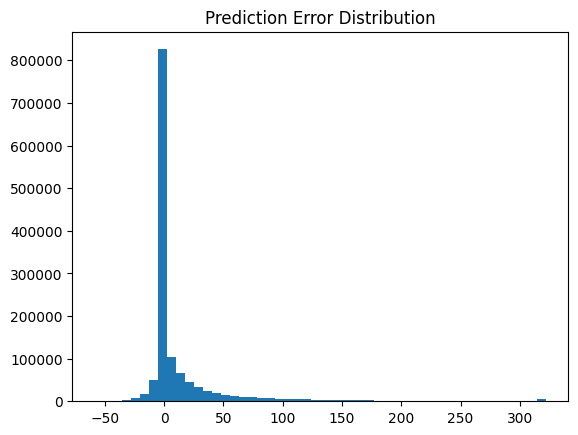

In [ ]:
import matplotlib.pyplot as plt
errors = y_test_capped - xgb_test_pred
pd.Series(errors).describe()
plt.hist(errors, bins=50)
plt.title("Prediction Error Distribution")
plt.show()

### 19. Error Analysis by Delay Severity (Buckets)

Global metrics like MAE can hide poor performance on specific subsets. Here, we calculate MAE specifically for different "buckets" of delay severity:

-   **0–15 min**: Minor delays (most common).
-   **15–30 min**: Moderate delays.
-   **30–60 min**: Significant delays.
-   **60+ min**: Severe delays.

*Why this matters*: A model might be great at predicting on-time flights (low MAE for 0-15) but terrible at predicting catastrophes (high MAE for 60+). This breakdown tells us where the model struggles.

In [ ]:
bins = [0, 15, 30, 60, 300]
labels = ["0–15", "15–30", "30–60", "60+"]

df_eval = pd.DataFrame({
    "true": y_test_capped,
    "pred": xgb_test_pred
})

df_eval["bucket"] = pd.cut(df_eval["true"], bins=bins, labels=labels)

df_eval.groupby("bucket").apply(
    lambda x: mean_absolute_error(x["true"], x["pred"])
)

/tmp/ipython-input-251372838.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_eval.groupby("bucket").apply(
/tmp/ipython-input-251372838.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_eval.groupby("bucket").apply(


,0
bucket,
0–15,6.088106
15–30,18.414565
30–60,37.096074
60+,110.760571


### 20. Sanity Check: Residual Correlation

We check the correlation between the **Predicted Value** and the **Error** (`Actual - Predicted`).

-   **Ideal Score**: Close to **0**.
-   **Positive Correlation**: The model tends to under-predict when it predicts high values.
-   **Interpretation**:
    - 1. If the score is near 0, the errors are random (homoscedasticity), which is ideal.
    - 2. If the score is high (positive or negative), the model consistently over/underestimates 
    certain ranges, suggesting a need for feature engineering or a more complex model.

In [ ]:
errors = y_test_capped - xgb_test_pred
residual_correlation_sanity = np.corrcoef(xgb_test_pred, errors)[0, 1]
print("residual_correlation_sanity",residual_correlation_sanity)

residual_correlation_sanity 0.16286673171666666
